#**Importing Libraries**

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory  #Ye function automatically   Images load karega , Labels bana dega , Dataset create karega

##ZIP Extract

In [43]:
from zipfile import ZipFile

zip_path = "/content/archive.zip"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

##Check Folder Structure


In [44]:
import os

os.listdir("/content")

['.config',
 'Testing',
 'Training',
 'best_brain_tumor_model.keras',
 'archive.zip',
 'sample_data']

In [45]:
train_path = "/content/Training"
test_path = "/content/Testing"

print("Training Classes:")
print(os.listdir(train_path))

print("\nTesting Classes:")
print(os.listdir(test_path))

Training Classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

Testing Classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


#**Dataset Information**

In [46]:
import os

train_path = "/content/Training"
test_path = "/content/Testing"

for folder in os.listdir(train_path):
    print(f"{folder} : {len(os.listdir(os.path.join(train_path, folder)))} images")

glioma_tumor : 826 images
meningioma_tumor : 822 images
no_tumor : 395 images
pituitary_tumor : 827 images


In [47]:
for folder in os.listdir(test_path):
    print(f"{folder} : {len(os.listdir(os.path.join(test_path, folder)))} images")

glioma_tumor : 100 images
meningioma_tumor : 115 images
no_tumor : 105 images
pituitary_tumor : 74 images


##Sample Images of Each Four Images

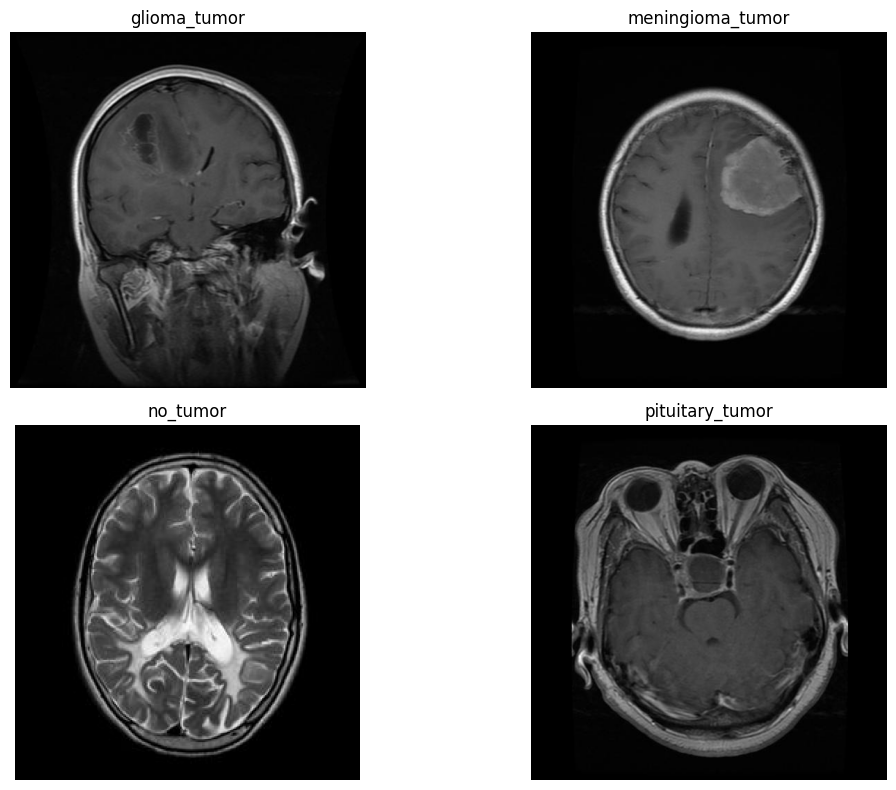

In [48]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(12,8))

classes = os.listdir(train_path)

for i, folder in enumerate(classes):

    image_name = os.listdir(os.path.join(train_path, folder))[0]

    image_path = os.path.join(train_path, folder, image_name)

    image = mpimg.imread(image_path)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")

plt.tight_layout()
plt.show()

##Image Size

In [49]:
print("Image Shape :", image.shape)

Image Shape : (512, 512, 3)


##Image Pixel Values

In [50]:
print("Data Type :", image.dtype)
print("Minimum Pixel :", image.min())
print("Maximum Pixel :", image.max())

Data Type : uint8
Minimum Pixel : 0
Maximum Pixel : 251


#**Image Preprocessing**

###Define Image size and Batch size

In [51]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

##Training Dataset

In [52]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_path,image_size=IMAGE_SIZE,batch_size=BATCH_SIZE,shuffle=True)

Found 2870 files belonging to 4 classes.


##Testing Dataset

In [53]:
test_dataset = tf.keras.utils.image_dataset_from_directory(test_path,image_size=IMAGE_SIZE,batch_size=BATCH_SIZE,shuffle=False)

Found 394 files belonging to 4 classes.


##Class Names

In [54]:
print(train_dataset.class_names)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


##Batch shape

In [55]:
print(train_dataset.class_names)

images, labels = next(iter(train_dataset))

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [56]:
print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : (32, 224, 224, 3)
Labels Shape : (32,)


In [57]:
print(labels)

tf.Tensor([2 3 2 3 0 1 1 0 3 3 2 1 3 0 3 0 1 0 2 3 3 0 0 2 3 3 1 1 3 1 0 1], shape=(32,), dtype=int32)


In [58]:
print(train_dataset.class_names)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


##Visualizing a Single Image

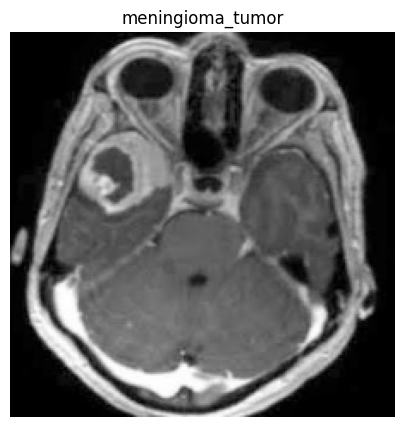

In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.imshow(images[31].numpy().astype("uint8"))
plt.title(train_dataset.class_names[int(labels[31])])
plt.axis("off")
plt.show()

##Visualizing Multiple Images

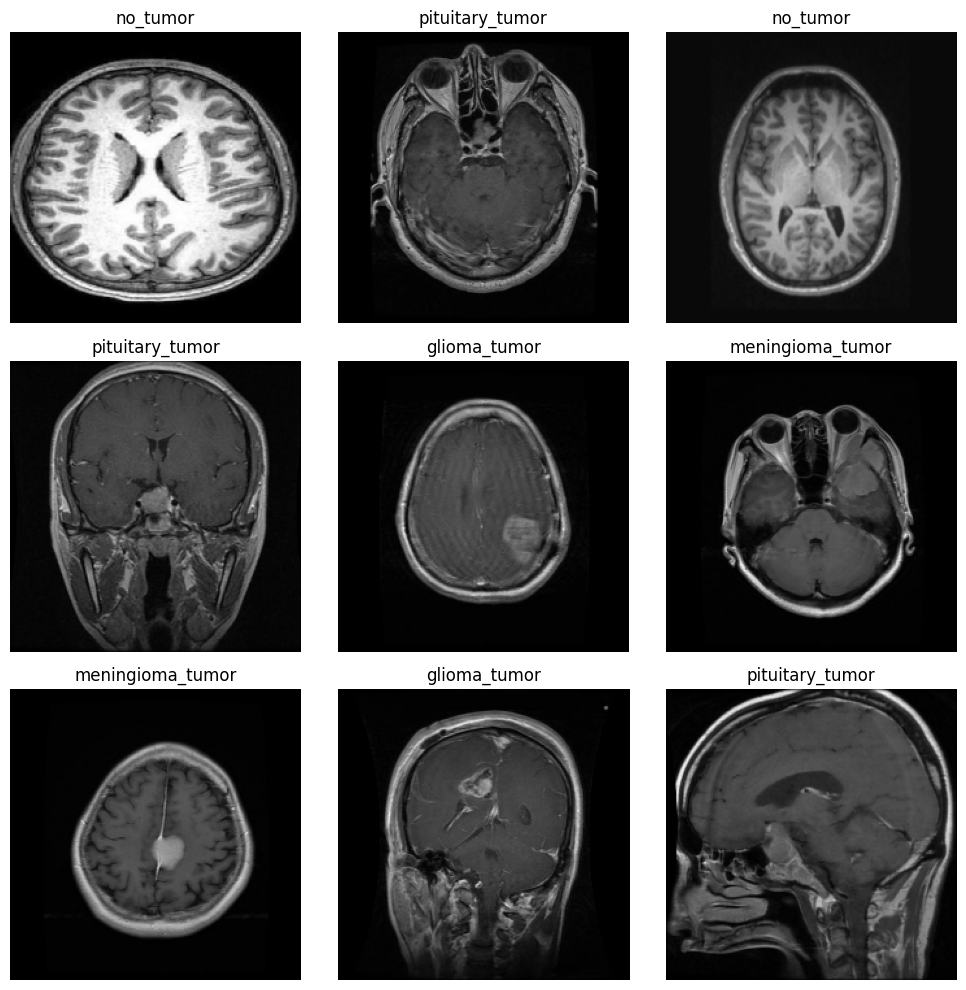

In [60]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_dataset.class_names[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

##Current Pipeline

Dataset Download ✅

↓

Extract Dataset ✅

↓

Understand Dataset ✅

↓

Image Analysis ✅

↓

TensorFlow Dataset ✅

↓

Batch Creation ✅

↓

Visual Verification ✅


#**Image Normalization**

In [61]:
print(images.dtype) #TensorFlow calculation ke liye decimal numbers use karega.
                    #CNN isi datatype pe train hota hai.

<dtype: 'float32'>


In [62]:
print(images[0, 100, 100]) # 83,83,83  --> Matlab ki teeno same hai RGB toh jabhi image black & white me dikh rhi hai

tf.Tensor([33.988846 33.988846 33.988846], shape=(3,), dtype=float32)


In [63]:
from tensorflow.keras.layers import Rescaling
normalization_layer = Rescaling(1./255)

In [64]:
normalized_images = normalization_layer(images)

In [65]:
print("Before Normalization:")
print(images[0,100,100])

print()

print("After Normalization:")
print(normalized_images[0,100,100])

Before Normalization:
tf.Tensor([33.988846 33.988846 33.988846], shape=(3,), dtype=float32)

After Normalization:
tf.Tensor([0.1332896 0.1332896 0.1332896], shape=(3,), dtype=float32)


#ABHI TAK KI PIPELINE

MRI Images

↓

Read Images

↓

Create Labels

↓

Resize (224×224)

↓

Convert to float32

↓

Normalize (0–255 → 0–1)

↓

Ready for CNN ✅

#**CNN Architect**

Input Image

↓

Conv2D

↓

ReLU

↓

MaxPooling

↓

Conv2D

↓

ReLU

↓

MaxPooling

↓

Flatten

↓

Dense

↓

Output Layer

##Import Layers

In [66]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [67]:
model = Sequential()

###Adding layers in Empty CNN

In [68]:
model.add(Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

In [69]:
model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

In [70]:
model.summary()  #Inse pata hota hai  ki ham feature extractor hai ye sab param 896,18496 matlab hai ki conv, pooling se ne itne chije sikhi hai har ke param ne

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

**Feature Extractor Done**


#### Flatten Layer

In [71]:
model.add(Flatten())

In [72]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

#**Classifier**

**dense layer** se hoga
mtlb cnv , pooling bhot imfo leli ab dense layer ye bolegi ki bhot info agyi ab me dedcide karunga ki image kis class ki hai

In [73]:
model.add(Dense(units=128,activation="relu"))
model.add(Dense(units=64,activation="relu"))

**Output Neuron**

4 neuron hi kyu kyuki 4 classes hai output

In [74]:
model.add(Dense(units=4,activation="softmax"))

In [75]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,915,908 (91.23 MB)

 Trainable params: 23,915,908 (91.23 MB)

 Non-trainable params: 0 (0.00 B)

#**Model Compilation**

In [76]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

#**Model Training**

###Callbacks before training the model

In [77]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

Callback 2 - ModelCheckpoint

In [78]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("best_brain_tumor_model.keras",monitor="val_accuracy",save_best_only=True)

In [79]:
history = model.fit(train_dataset,validation_data=test_dataset,epochs=20,callbacks=[early_stopping, checkpoint])

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.6582 - loss: 22.2369 - val_accuracy: 0.5533 - val_loss: 1.9211
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9084 - loss: 0.2428 - val_accuracy: 0.6624 - val_loss: 2.8941
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9638 - loss: 0.1240 - val_accuracy: 0.6523 - val_loss: 3.3799
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9798 - loss: 0.0680 - val_accuracy: 0.7005 - val_loss: 2.2785
